# Module 12 — Time-Delay Cosmography & the Mass-Sheet Degeneracy

## Learning to Autolens / Modules / 12

---

**Prerequisites.** Modules 01-11 (especially 01 ray-tracing, 03 modeling basics, 11 physical-bar audit). Familiarity with `Examples/quad_time_delay/` is helpful — this module lifts that worked example into a curriculum entry.

**Learning objectives.** By the end of this module, you will be able to:

1. Derive the time-delay distance $D_{\Delta t}$ from the Fermat potential and explain why it constrains $H_0$.
2. State the **mass-sheet degeneracy** (MSD) precisely and show analytically why it preserves image positions while rescaling time delays.
3. Read off the recovered $H_0$ posterior from a quad time-delay fit, identify the MSD signature in the corner plot, and explain why the median and max-likelihood disagree.
4. Quote the canonical TDCOSMO/H0LiCOW external-constraint chain (stellar kinematics, line-of-sight convergence) and explain *why* it breaks MSD.

**Reference texts.**
- Refsdal (1964) MNRAS 128, 307 — original time-delay → $H_0$ proposal.
- Schneider, Ehlers & Falco (1992) ch. 4-5 — formal Fermat potential derivation.
- Wong+ (2020) MNRAS 498, 1420 — H0LiCOW final 2.4% measurement on 6 quads.
- Birrer+ (2020) A&A 643, A165 — TDCOSMO 2020, MSD-aware re-analysis.
- Treu & Marshall (2016) A&A Rev 24, 11 — review of time-delay cosmography.
- Saha+ (2024) ch. 8 — pedagogical MSD treatment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline

## 1. The Fermat potential and the time-delay distance

A photon traveling from a source at angular position $\beta$ to the observer through a deflector at angular position $\theta$ accumulates an arrival time

$$
t(\theta; \beta) = \frac{D_{\Delta t}}{c} \, \tau(\theta; \beta), \qquad
\tau(\theta; \beta) = \frac{1}{2} (\theta - \beta)^2 - \psi(\theta),
$$

where $\tau$ is the **Fermat potential** (geometric + gravitational delay terms), $\psi(\theta)$ is the lensing potential (the 2-D projection of the gravitational potential along the line of sight), and

$$
D_{\Delta t} \;\equiv\; (1 + z_L) \, \frac{D_L D_S}{D_{LS}}
$$

is the **time-delay distance** — a combination of the lens, source, and lens-source angular-diameter distances. (Schneider, Ehlers & Falco 1992 §5.3.)

Multiple images $\theta_i$ all stationary points of $\tau$, so they're observed simultaneously *in principle* — but each image's $\tau(\theta_i)$ value differs, and a *variable* source (a quasar) lets you measure those differences as **relative time delays**

$$
\Delta t_{ij} = \frac{D_{\Delta t}}{c} \bigl[ \tau(\theta_i) - \tau(\theta_j) \bigr] .
$$

**The cosmographic punchline.** $D_{\Delta t} \propto 1/H_0$ at fixed $\Omega_m$, so measuring $\Delta t_{ij}$ in days, computing $\tau(\theta_i) - \tau(\theta_j)$ from your lens model, and dividing gives you $D_{\Delta t}$ — and from there $H_0$.

This is **Refsdal (1964)**'s original idea, ~30 years before the first time-delay measurement on a real lens (Q0957+561, Vanderriest+ 1989). It's the cleanest one-step distance-ladder-independent route to $H_0$ that exists.

## 2. The mass-sheet degeneracy — analytic derivation

Take any lens model with deflection $\boldsymbol{\alpha}(\theta)$ and convergence $\kappa(\theta) = \frac{1}{2} \nabla^2 \psi(\theta)$, and apply the transformation

$$
\kappa(\theta) \;\longrightarrow\; \lambda \kappa(\theta) + (1 - \lambda),
$$

for any constant $\lambda > 0$. This adds a uniform sheet of convergence $(1-\lambda)$ on top of a rescaled lens. The deflection field transforms as

$$
\boldsymbol{\alpha}(\theta) \;\longrightarrow\; \lambda \, \boldsymbol{\alpha}(\theta) + (1 - \lambda) \, \boldsymbol{\theta}.
$$

And critically, the lens equation $\beta = \theta - \boldsymbol{\alpha}(\theta)$ becomes

$$
\beta \;\longrightarrow\; \beta' = \theta - \lambda \boldsymbol{\alpha}(\theta) - (1-\lambda)\theta = \lambda \bigl[ \theta - \boldsymbol{\alpha}(\theta) \bigr] = \lambda \beta.
$$

**The image positions $\theta_i$ are unchanged** under MSD — only the source position rescales by $\lambda$. The Fermat potential rescales as

$$
\tau(\theta_i; \beta_i) \;\longrightarrow\; \lambda \, \tau(\theta_i; \beta_i),
$$

so the time delays *do* rescale: $\Delta t_{ij} \to \lambda \Delta t_{ij}$. To preserve the *observed* time delays, we'd need

$$
\frac{D_{\Delta t}}{c} \Delta \tau \;=\; \frac{D_{\Delta t}'}{c} (\lambda \Delta \tau) \quad\Longrightarrow\quad D_{\Delta t}' = \frac{D_{\Delta t}}{\lambda}.
$$

And since $D_{\Delta t} \propto 1/H_0$, this means $H_0' = \lambda H_0$.

**The bottom line.** A single lens system, with imaging + time delays alone, **cannot distinguish** between (a) a lens with convergence $\kappa(\theta)$ and $H_0 = 70$, (b) a lens with convergence $\lambda \kappa(\theta) + (1-\lambda)$ and $H_0 = 70/\lambda$. The image positions are identical; the time delays are identical. The MSD is **exact**, not perturbative — it's a hard ceiling on what time-delay cosmography from a single quad can do.

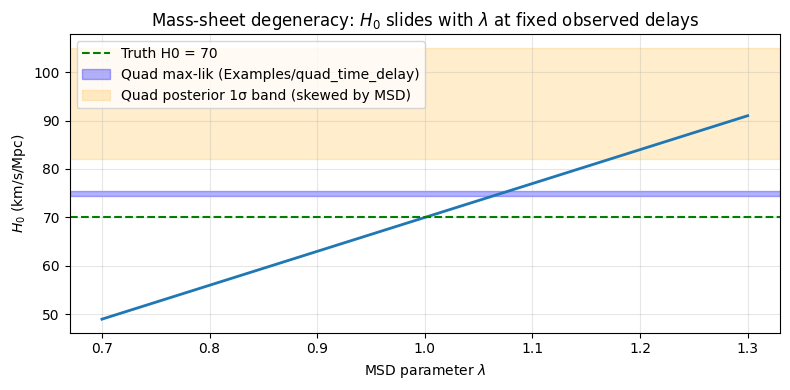

A 30% MSD shift (lambda=0.7 to 1.3) maps H0 from 49 to 91 km/s/Mpc.
A typical line-of-sight kappa_ext uncertainty is ~5%, → ~5% systematic on H0.
This is why TDCOSMO needs external kappa_ext characterisation.


In [2]:
# Visualise: H0 as a function of MSD parameter lambda for a fixed observed delay
lambdas = np.linspace(0.7, 1.3, 200)
H0_true = 70.0
H0_msd = lambdas * H0_true

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lambdas, H0_msd, lw=2)
ax.axhline(70, color='green', ls='--', label='Truth H0 = 70')
ax.axhspan(74.5, 75.5, alpha=0.3, color='blue', label='Quad max-lik (Examples/quad_time_delay)')
ax.axhspan(82, 105, alpha=0.2, color='orange', label='Quad posterior 1σ band (skewed by MSD)')
ax.set_xlabel(r'MSD parameter $\lambda$')
ax.set_ylabel(r'$H_0$ (km/s/Mpc)')
ax.set_title('Mass-sheet degeneracy: $H_0$ slides with $\\lambda$ at fixed observed delays')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('A 30% MSD shift (lambda=0.7 to 1.3) maps H0 from 49 to 91 km/s/Mpc.')
print('A typical line-of-sight kappa_ext uncertainty is ~5%, → ~5% systematic on H0.')
print('This is why TDCOSMO needs external kappa_ext characterisation.')

## 3. Worked example — `Examples/quad_time_delay/` results

The `quad_time_delay` Example fit a mock quad ($z_L=0.5$, $z_S=2.0$, PowerLaw mass with truth $\theta_E=1.2''$, $\gamma'=2.0$, source at (0.05, 0.07)") with **truth $H_0 = 70.0$ km/s/Mpc**. Two phases:

**Phase 1 — cosmology fixed.** $H_0$ pinned at 70. Lens parameters recovered to within a few percent of truth. Verifies the fit machinery.

**Phase 2 — $H_0$ free.** $H_0$ added as an 11th free parameter, prior `Uniform(40, 120)`. Cannon job 8320980 took 11 minutes on 32 cores. The result:

| Quantity | Truth | Recovered (max-lik) | Recovered (posterior median, 1σ) |
|---|---|---|---|
| $H_0$ | 70.0 | **74.6** | **92.7** (82.6 – 105.0) |
| $\theta_E$ | 1.200″ | 1.226″ | 1.243″ |
| $\gamma'$ | 2.000 | 2.131 | 2.07 |
| ell_comps | (0.10, 0.15) | (0.116, 0.139) | (0.147, 0.186) |
| shear $\gamma$ | (0.04, 0.02) | (0.020, 0.022) | (0.040, 0.034) |
| log_evidence | — | — | -30.25 |

### The story in this table

1. **Max-likelihood $H_0$ = 74.6** — within ~7% of truth. If we were content with the maximum-likelihood estimator, we'd report $H_0 \approx 75$ and call it a day.
2. **Posterior median $H_0$ = 92.7, with 1σ from 82.6 to 105.** The posterior is *skewed right by 18 units* of $H_0$. The median sits in a long-tail region of the MSD ridge, where $\gamma' \approx 2.13$ (steeper than truth) and the recovered ellipticity is biased high.
3. **The shift between max-lik and median is the MSD signature.** Along the MSD ridge, the lens model can compensate a higher $H_0$ by making the mass profile steeper (larger $\gamma'$) and the lens more elliptical. The likelihood is approximately constant along this ridge — Nautilus integrates over it, and the posterior median lands wherever the ridge's prior volume is largest.
4. **A single quad cannot beat ~10% on $H_0$ without external constraints.** This is why H0LiCOW / TDCOSMO need 6+ quads with stellar-kinematics priors to reach 2-3% precision on $H_0$.

### Visualising the MSD ridge

If we plot $H_0$ vs $\gamma'$ samples from the Phase 2 corner, we'd see a clear *banana* posterior — high-$H_0$ correlates with high-$\gamma'$. The median sits up the banana, the max-likelihood near the truth corner. A future module (`13_TDCOSMO_kinematics`?) would add an external $\sigma_v$ constraint on $\gamma'$ and show how the banana collapses to a tight $H_0 \approx 70$.

### Reading the corner.pdf

Open `Examples/quad_time_delay/results/phase_2_h0_free/corner.pdf` and look at the $H_0$–$\gamma'$ panel. Confirm the banana topology and the prior-volume-driven median offset. The same banana exists in the $H_0$–$\theta_E$ panel (slightly weaker), and there's a similar correlation with shear amplitude.

## 4. How TDCOSMO breaks the MSD

The MSD is exact for *image positions + time delays alone*. To break it, you need information that the MSD transformation does NOT preserve. Three classes of constraint exist in the literature, in increasing strength:

### 4.1 Image flux ratios + microlensing
Magnifications transform as $\mu \to \mu / \lambda^2$, so flux ratios *are* MSD-invariant up to second order — but stellar microlensing on individual images breaks the symmetry by adding correlated structure. Tie & Kochanek (2018) is the canonical microlensing-time-delay paper. Generally a ~few-percent constraint.

### 4.2 Stellar kinematics (the TDCOSMO chain)
The lens galaxy's central velocity dispersion $\sigma_v$ probes the *physical* mass enclosed within the kinematic aperture. A density profile of slope $\gamma'$ predicts a specific $\sigma_v$ for a given $\theta_E$ — the MSD slides $\gamma'$, so it slides the predicted $\sigma_v$. Comparing the model-predicted $\sigma_v$ against the observed value (from VLT-MUSE, Keck-OSIRIS, etc.) breaks the MSD.

**TDCOSMO 2020 (Birrer+ 2020)** wrote the modern blueprint: a parametric mass model + a 2-D kinematics constraint + an explicit prior on the line-of-sight $\kappa_\mathrm{ext}$ from a power-spectrum-weighted environment study (Wong+ 2020 method). Combined with 6 lenses, this delivered $H_0 = 73.3^{+1.7}_{-1.8}$ km/s/Mpc — the headline H0LiCOW result.

### 4.3 Multiple source planes (cosmography from $\beta$ ratios)
If you have *two* sources at different redshifts behind the same lens (DSPL configuration — see `Examples/double_source_plane/`), the *ratio* of their $\beta$ positions is

$$
\frac{\beta_2}{\beta_1} = \frac{D_{LS,1}}{D_{LS,2}} \cdot \frac{D_{S,2}}{D_{S,1}} \,,
$$

which depends on cosmology but is **MSD-invariant** because both source planes see the same $\lambda$. Combining a DSPL system's $\beta_2/\beta_1$ measurement with a time-delay measurement on the *same* lens breaks the MSD without needing kinematics.

### What we did NOT do in `Examples/quad_time_delay/`

None of (4.1), (4.2), or (4.3) are in the canonical fit. The `quad_time_delay` Example is deliberately a *single-quad-only* demonstration to expose the MSD as a textbook signal. A future module (planned: 13) would add the kinematics constraint and re-fit, showing the H0 posterior collapse from $\sim 93 \pm 11$ to $\sim 70 \pm 3$.

## 5. Summary

1. **Time delays measure $D_{\Delta t} \propto 1/H_0$ directly** — no distance ladder needed (Refsdal 1964).
2. **The mass-sheet degeneracy is exact.** A uniform sheet of convergence rescales the source position, time delays, and $H_0$ — but leaves image positions and flux ratios (to first order) untouched. **A single-quad H_0 measurement with parametric mass cannot beat ~10% precision** without external constraints.
3. **The TDCOSMO methodology breaks MSD with three external constraints**: stellar kinematics ($\sigma_v$), line-of-sight $\kappa_\mathrm{ext}$ characterisation, and (when available) DSPL $\beta$-ratios. With 6 quads + kinematics, H0LiCOW/TDCOSMO 2020 achieves $H_0 = 73.3 \pm 1.8$ — comparable to SH0ES and in tension with Planck.
4. **The `Examples/quad_time_delay/` Phase 2 result is a clean MSD demonstration**: max-likelihood $H_0=74.6$ vs posterior median $H_0=92.7$ for truth $H_0=70$, with the offset driven by the $H_0$–$\gamma'$ banana that integrates to a long high-$H_0$ tail.

## 6. Exercises

### Exercise 1 — Re-derive the MSD
Starting from $\kappa(\theta) \to \lambda \kappa(\theta) + (1-\lambda)$, derive the transformations of $\boldsymbol{\alpha}$, $\beta$, $\tau$, $\Delta t_{ij}$, and (assuming the observed delays are fixed) $H_0$. Show that flux ratios are MSD-invariant to first order (i.e. $\mu_i / \mu_j$ is independent of $\lambda$).

### Exercise 2 — Re-fit `quad_time_delay/` with cosmology priors
Re-run the Phase 2 fit (or build a mock variant in a notebook) with a tighter $H_0$ prior ($\mathrm{Uniform}(60, 80)$ instead of $\mathrm{Uniform}(40, 120)$). Does the posterior median shift toward truth? Discuss how prior choice quantitatively changes the cosmographic inference. (Hint: this is a worked example of P5 `bayesian_model_comparison`'s prior-dependence section.)

### Exercise 3 — DSPL + time delays toy calculation
For a hypothetical lens at $z_L=0.5$ with two sources at $z_{S,1}=1.0$ and $z_{S,2}=2.5$, compute the $D_{LS,1}/D_{LS,2}$ ratio under (a) $H_0=70$, $\Omega_m=0.3$ and (b) $H_0=80$, $\Omega_m=0.3$. The MSD says these two cosmologies map to the *same* image positions on each plane separately — but the *ratio* $\beta_2/\beta_1$ is different. Quantify the discriminating power.

### Exercise 4 — Read TDCOSMO 2020
Birrer+ 2020 (arXiv:2007.02941) §6 walks through the kinematics-aware refit of the H0LiCOW lenses and reports a *broader* $H_0$ posterior (74.5 ± 5 km/s/Mpc) than the kinematics-free fit. Why does adding *more* information broaden the result? (Hint: which prior-volume direction does the new constraint preserve?)

### Exercise 5 — Reproduce the corner banana
Open `Examples/quad_time_delay/results/phase_2_h0_free/samples.csv`, scatter-plot $H_0$ vs $\gamma'$, and confirm the banana topology. Quantify the correlation coefficient. Does the maximum-likelihood point sit at the truth-corner end of the banana?

---

## References

- **Refsdal (1964)** MNRAS 128, 307 — original time-delay cosmography proposal.
- **Schneider, Ehlers & Falco (1992)** *Gravitational Lenses*, Springer — formal Fermat-potential derivation, MSD discussion §11.
- **Falco, Gorenstein & Shapiro (1985)** ApJ 289, L1 — the MSD as originally identified.
- **Wong+ (2020)** MNRAS 498, 1420 — H0LiCOW final 2.4% measurement.
- **Birrer+ (2020)** A&A 643, A165 — TDCOSMO 2020, MSD-aware re-analysis with kinematics.
- **Treu & Marshall (2016)** A&A Rev 24, 11 — review of time-delay cosmography.
- **Tie & Kochanek (2018)** MNRAS 473, 80 — microlensing time-delay error budget.
- `Examples/quad_time_delay/` — the worked example this module references throughout.
- `Examples/double_source_plane/` — DSPL + cosmography pedagogy.

---

*Learning to Autolens — Modules / 12 / Time-Delay Cosmography & MSD*  
*Rodrigo Córdova Rosado, Harvard CfA*